# HPO Analysis

This notebook analyses the outcomes of the hyperparameter optimisation conducted for both, QBC Deep Ensemble and Marker-Directed sampling methods.

### Imports

In [14]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from omegaconf import OmegaConf
import numpy as np

def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'src').exists() and (candidate / 'results').exists():
            return candidate
    raise FileNotFoundError(f'Could not locate repo root from {start}')


REPO_ROOT = find_repo_root(Path.cwd())
RESULTS_ROOT = REPO_ROOT / 'hpo' / 'results' / 'qbc_deep_ensemble'
STAGE1_ROOT = sorted((RESULTS_ROOT / 'stage1_policy_search').iterdir())[-1]
STAGE2_ROOT = sorted((RESULTS_ROOT / 'stage2_schedule_search').iterdir())[-1]

CFG_STAGE1 = OmegaConf.to_container(
    OmegaConf.load(REPO_ROOT / 'hpo' / 'workflow_configs' / 'qbc_deep_ensemble' / 'sm4.yaml'),
    resolve=True,
)

print('REPO_ROOT:', REPO_ROOT)
print('STAGE1_ROOT:', STAGE1_ROOT)
print('STAGE2_ROOT:', STAGE2_ROOT)

REPO_ROOT: /Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems
STAGE1_ROOT: /Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems/hpo/results/qbc_deep_ensemble/stage1_policy_search/qbc_deep_ensemble_policy_search_20260302_165157
STAGE2_ROOT: /Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems/hpo/results/qbc_deep_ensemble/stage2_schedule_search/qbc_deep_ensemble_schedule_search_20260303_080753


## 1. QBC Deep Ensemble

### Load Artifacts

Each HPO row is reconstructed from `matrix.tsv, `hpo_status.json`, the final row of `qbc/history.jsonl`, and round telemetry. The final row in `history.jsonl` is the main HPO outcome for ranking.

In [15]:
def parse_override_text(text: str) -> dict[str, str]:
    out: dict[str, str] = {}
    for chunk in str(text or '').split(';;'):
        chunk = chunk.strip()
        if not chunk or '=' not in chunk:
            continue
        key, value = chunk.split('=', 1)
        out[key] = value
    return out


def load_hpo_run(hpo_root: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    matrix = pd.read_csv(hpo_root / 'matrix.tsv', sep='\t')
    rows = []
    round_rows = []

    for row in matrix.to_dict(orient='records'):
        run_root = hpo_root / 'runs' / row['cfg_id']
        status_path = run_root / 'hpo_status.json'
        history_path = run_root / 'qbc' / 'history.jsonl'
        telemetry_path = run_root / 'telemetry' / 'round_telemetry.csv'
        if not status_path.exists() or not history_path.exists():
            continue

        status = json.loads(status_path.read_text())
        if int(status.get('return_code', 1)) != 0:
            continue

        history = [json.loads(line) for line in history_path.read_text().splitlines() if line.strip()]
        if not history:
            continue

        final = history[-1]
        rec = dict(row)
        rec.update({f'final_{k}': v for k, v in final.items()})
        rec['run_root_local'] = str(run_root)
        rec.update(parse_override_text(row.get('stage1_overrides', '')))
        rows.append(rec)

        overrides = parse_override_text(row.get('stage1_overrides', ''))

        if telemetry_path.exists():
            telemetry = pd.read_csv(telemetry_path)
        else:
            telemetry = pd.DataFrame(history)
        telemetry['cfg_id'] = row['cfg_id']
        telemetry['seed'] = row['seed']
        telemetry['budget'] = row['budget']
        telemetry['hpo_root'] = str(hpo_root)
        for key, value in overrides.items():
            telemetry[key] = value
        round_rows.append(telemetry)

    summary = pd.DataFrame(rows)
    rounds = pd.concat(round_rows, ignore_index=True) if round_rows else pd.DataFrame()
    return summary, rounds


stage1_df, stage1_rounds = load_hpo_run(STAGE1_ROOT)
stage2_df, stage2_rounds = load_hpo_run(STAGE2_ROOT)

print('stage1 rows:', len(stage1_df), 'stage1 round rows:', len(stage1_rounds))
print('stage2 rows:', len(stage2_df), 'stage2 round rows:', len(stage2_rounds))

stage1 rows: 48 stage1 round rows: 720
stage2 rows: 9 stage2 round rows: 279


### Search Setup

In [16]:
def config_setup_table(cfg: dict, stage_label: str) -> pd.DataFrame:
    stage_key = {'stage1': 'policy', 'stage2': 'refine'}.get(stage_label, stage_label)
    stage_cfg = cfg['stages'][stage_key]
    searched = stage_cfg.get('search', {}).get('stage1', {})
    fixed = stage_cfg.get('fixed_overrides', {}).get('stage1', [])
    return pd.DataFrame(
        [
            {
                'stage': stage_label,
                'budget_axis': str(stage_cfg.get('budget', '')),
                'seed_axis': ', '.join(stage_cfg.get('seeds', [])),
                'searched_params': ', '.join(searched.keys()),
                'fixed_stage1_overrides': '; '.join(fixed),
                'objective': 'final eval_rmse (lower is better)',
                'n_matrix_rows': len(pd.read_csv((STAGE1_ROOT if stage_label == 'stage1' else STAGE2_ROOT) / 'matrix.tsv', sep='\t')),
            }
        ]
    )


display(config_setup_table(CFG_STAGE1, 'stage1'))
display(config_setup_table(CFG_STAGE1, 'stage2'))

,stage,budget_axis,seed_axis,searched_params,fixed_stage1_overrides,objective,n_matrix_rows
0,stage1,b1024,"s01, s02, s03","qbc_M, active.disagreement.metric, active.dive...",qbc_enable_logging=true; active.log_every=5; q...,final eval_rmse (lower is better),48


,stage,budget_axis,seed_axis,searched_params,fixed_stage1_overrides,objective,n_matrix_rows
0,stage2,b4096,"s01, s02, s03","qbc_n0, qbc_K, qbc_T, qbc_P",qbc_enable_logging=true; active.log_every=5; q...,final eval_rmse (lower is better),9


### Stage 1
-> find optimal policy

In [17]:
columns = [
    'qbc_M',
    'active.disagreement.metric',
    'active.diversity.preselect_factor',
    'active.diversity.uncertainty_weight',
    'active.diversity.distance_weight',
]

stage1_ranked = (
    stage1_df.groupby(columns, dropna=False)
    .agg(
        n_seeds=('seed', 'nunique'),
        mean_final_eval_rmse=('final_eval_rmse', 'mean'),
        std_final_eval_rmse=('final_eval_rmse', 'std'),
        min_final_eval_rmse=('final_eval_rmse', 'min'),
        max_final_eval_rmse=('final_eval_rmse', 'max'),
        mean_final_eval_mse=('final_eval_mse', 'mean'),
        mean_final_train_seconds=('final_train_seconds', 'mean'),
        mean_final_round_seconds=('final_round_seconds', 'mean'),
    )
    .reset_index()
    .sort_values(['mean_final_eval_rmse', 'std_final_eval_rmse'])
)

stage1_param_cols = columns.copy()
best_stage1 = stage1_ranked.iloc[0].copy()

print("Stage 1 ranked configurations:")
display(stage1_ranked.head(3))

stage1_summary_table = (
    stage1_ranked[
        [
            'active.disagreement.metric',
            'qbc_M',
            'active.diversity.preselect_factor',
            'active.diversity.uncertainty_weight',
            'mean_final_eval_rmse',
            'std_final_eval_rmse',
            'min_final_eval_rmse',
            'max_final_eval_rmse',
            'mean_final_round_seconds',
            'mean_final_train_seconds',
            'n_seeds',
        ]
    ]
    .rename(
        columns={
            'active.disagreement.metric': 'metric',
            'qbc_M': 'qbc_M',
            'active.diversity.preselect_factor': 'preselect_factor',
            'active.diversity.uncertainty_weight': 'uncertainty_weight',
            'mean_final_eval_rmse': 'rmse_mean',
            'std_final_eval_rmse': 'rmse_std',
            'min_final_eval_rmse': 'rmse_min',
            'max_final_eval_rmse': 'rmse_max',
            'mean_final_round_seconds': 'round_seconds_mean',
            'mean_final_train_seconds': 'train_seconds_mean',
        }
    )
    .round(
        {
            'rmse_mean': 6,
            'rmse_std': 6,
            'rmse_min': 6,
            'rmse_max': 6,
            'round_seconds_mean': 2,
            'train_seconds_mean': 2,
        }
    )
)

print("Stage 1 summary table:")
display(stage1_summary_table)


Stage 1 ranked configurations:


,qbc_M,active.disagreement.metric,active.diversity.preselect_factor,active.diversity.uncertainty_weight,active.diversity.distance_weight,n_seeds,mean_final_eval_rmse,std_final_eval_rmse,min_final_eval_rmse,max_final_eval_rmse,mean_final_eval_mse,mean_final_train_seconds,mean_final_round_seconds
8,5,member_l2_mean,3,0.6,0.4,3,0.005789,0.000158,0.005671,0.005969,0.000034,29.346868,30.315667
14,5,variance_mean,5,0.6,0.4,3,0.005849,0.000076,0.005787,0.005933,0.000034,29.202939,30.129887
0,3,member_l2_mean,3,0.6,0.4,3,0.005897,0.000366,0.005489,0.006196,0.000035,17.567543,18.275189


Stage 1 summary table:


,metric,qbc_M,preselect_factor,uncertainty_weight,rmse_mean,rmse_std,rmse_min,rmse_max,round_seconds_mean,train_seconds_mean,n_seeds
8,member_l2_mean,5,3,0.6,0.005789,0.000158,0.005671,0.005969,30.32,29.35,3
14,variance_mean,5,5,0.6,0.005849,0.000076,0.005787,0.005933,30.13,29.20,3
0,member_l2_mean,3,3,0.6,0.005897,0.000366,0.005489,0.006196,18.28,17.57,3
4,variance_mean,3,3,0.6,0.006356,0.000768,0.005675,0.007188,18.34,17.72,3
12,variance_mean,5,3,0.6,0.006442,0.001101,0.005566,0.007678,30.50,29.66,3
6,variance_mean,3,5,0.6,0.006487,0.000842,0.005569,0.007222,18.33,17.60,3
2,member_l2_mean,3,5,0.6,0.006517,0.000825,0.005948,0.007464,18.35,17.55,3
15,variance_mean,5,5,0.8,0.006600,0.000352,0.006288,0.006982,30.38,29.44,3
9,member_l2_mean,5,3,0.8,0.006627,0.000530,0.006305,0.007239,30.24,29.27,3
13,variance_mean,5,3,0.8,0.006927,0.000751,0.006336,0.007772,30.17,29.32,3


In [18]:
for col in columns:
    print(f'Effect of {col} on final_eval_rmse:')
    summary = (
        stage1_df.groupby(col, dropna=False)['final_eval_rmse']
        .agg(['mean', 'std', 'min', 'max', 'count'])
        .sort_index()
        .round(6)
    )
    display(summary)


Effect of qbc_M on final_eval_rmse:


,mean,std,min,max,count
qbc_M,,,,,
3,0.007065,0.001248,0.005489,0.009711,24
5,0.006536,0.000780,0.005566,0.008585,24


Effect of active.disagreement.metric on final_eval_rmse:


,mean,std,min,max,count
active.disagreement.metric,,,,,
member_l2_mean,0.006843,0.001119,0.005489,0.009711,24
variance_mean,0.006758,0.001028,0.005566,0.009088,24


Effect of active.diversity.preselect_factor on final_eval_rmse:


,mean,std,min,max,count
active.diversity.preselect_factor,,,,,
3,0.006703,0.001006,0.005489,0.009088,24
5,0.006898,0.001132,0.005569,0.009711,24


Effect of active.diversity.uncertainty_weight on final_eval_rmse:


,mean,std,min,max,count
active.diversity.uncertainty_weight,,,,,
0.6,0.006287,0.000799,0.005489,0.008585,24
0.8,0.007314,0.001061,0.006213,0.009711,24


Effect of active.diversity.distance_weight on final_eval_rmse:


,mean,std,min,max,count
active.diversity.distance_weight,,,,,
0.2,0.007314,0.001061,0.006213,0.009711,24
0.4,0.006287,0.000799,0.005489,0.008585,24


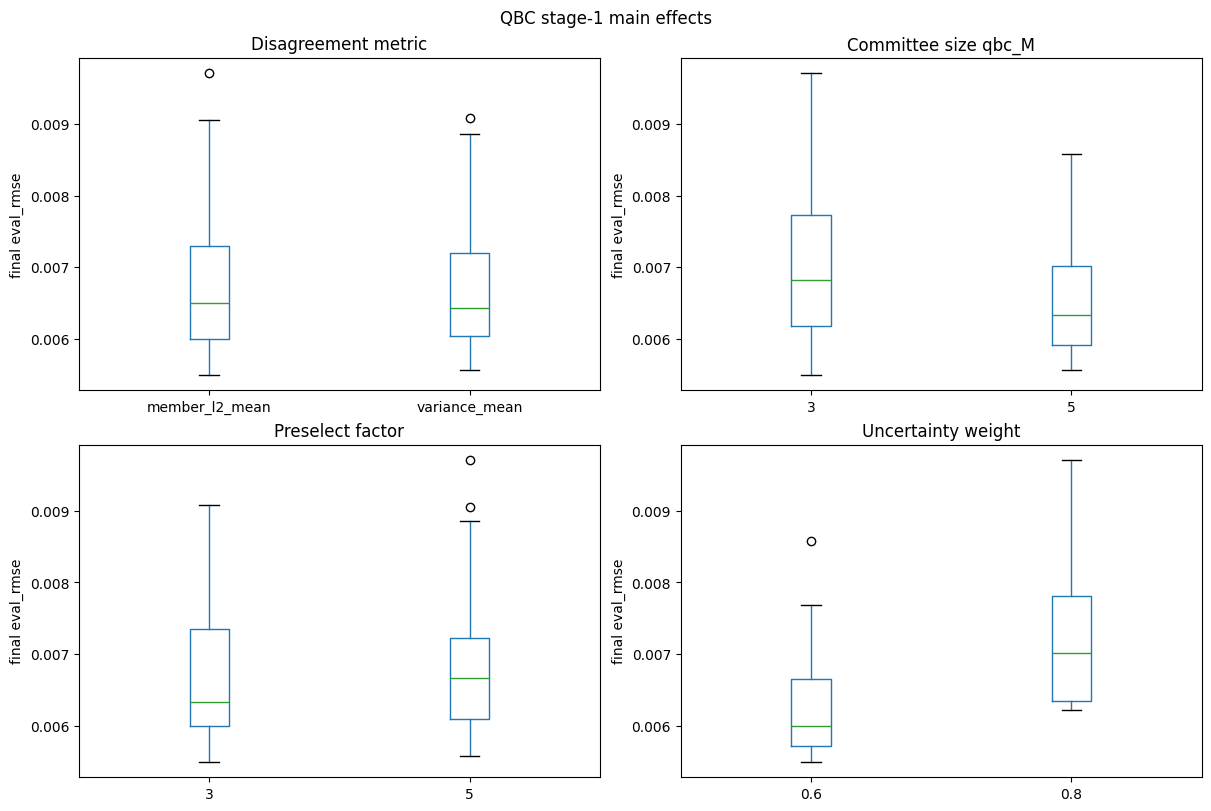

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

effect_specs = [
    ('active.disagreement.metric', 'Disagreement metric'),
    ('qbc_M', 'Committee size qbc_M'),
    ('active.diversity.preselect_factor', 'Preselect factor'),
    ('active.diversity.uncertainty_weight', 'Uncertainty weight'),
]

for ax, (col, title) in zip(axes.flat, effect_specs):
    plot_df = stage1_df[[col, 'final_eval_rmse']].copy().sort_values(col)
    plot_df.boxplot(column='final_eval_rmse', by=col, ax=ax, grid=False)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('final eval_rmse')

plt.suptitle('QBC stage-1 main effects')
plt.show()

## Stage 1 Top Configurations Over Rounds

Round traces explain why good settings work. The goal here is not only to see who wins, but whether strong settings keep selecting informative points and improving late in the run.

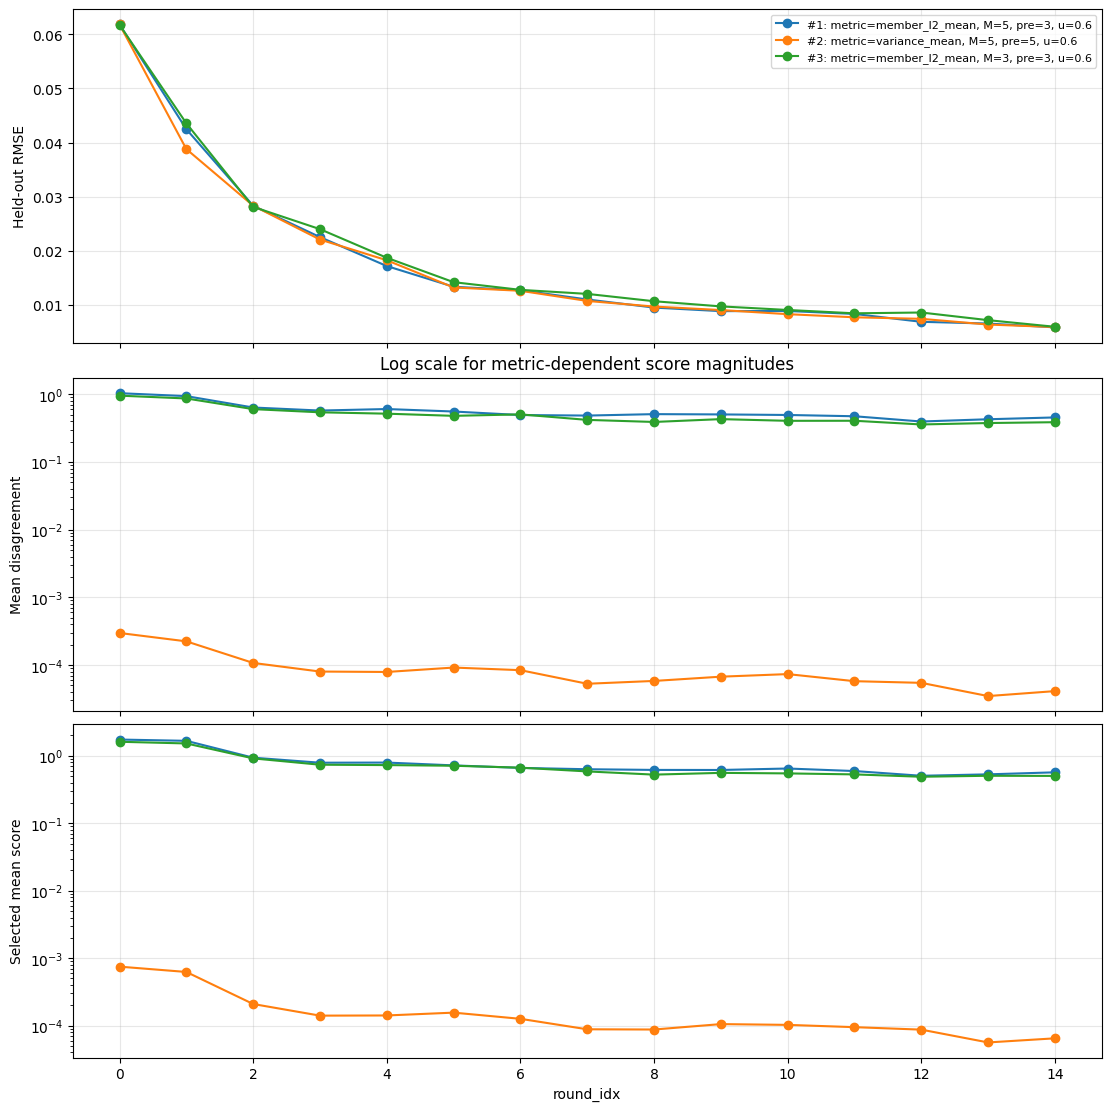

In [20]:
top_configs = stage1_ranked.head(3)[stage1_param_cols].to_dict(orient='records')

def filter_by_config(df: pd.DataFrame, cfg: dict[str, object]) -> pd.DataFrame:
    mask = pd.Series(True, index=df.index)
    for key, value in cfg.items():
        mask &= df[key].astype(str) == str(value)
    return df.loc[mask].copy()


fig, axes = plt.subplots(3, 1, figsize=(11, 11), sharex=True, constrained_layout=True)
metrics = [
    ('eval_rmse', 'Held-out RMSE'),
    ('mean_disagreement', 'Mean disagreement'),
    ('selected_mean_score', 'Selected mean score'),
]

for idx, cfg in enumerate(top_configs, start=1):
    cfg_rounds = filter_by_config(stage1_rounds, cfg)
    curve = cfg_rounds.groupby('round_idx')[['eval_rmse', 'mean_disagreement', 'selected_mean_score']].mean().reset_index()
    label = (
        f"#{idx}: metric={cfg['active.disagreement.metric']}, M={cfg['qbc_M']}, "
        f"pre={cfg['active.diversity.preselect_factor']}, u={cfg['active.diversity.uncertainty_weight']}"
    )
    for ax, (metric, title) in zip(axes, metrics):
        ax.plot(curve['round_idx'], curve[metric], marker='o', label=label)
        ax.set_ylabel(title)
        ax.grid(alpha=0.3)

axes[1].set_yscale('log')
axes[2].set_yscale('log')
axes[1].set_title('Log scale for metric-dependent score magnitudes')
axes[-1].set_xlabel('round_idx')
axes[0].legend(fontsize=8)
plt.show()



## Round Telemetry

of stage 1 winner

,final_eval_rmse,final_round_seconds,final_mean_disagreement,final_selected_mean_score
seed,,,,
s01,0.005671,29.825471,0.323735,0.402536
s02,0.005728,30.660613,0.587434,0.719418
s03,0.005969,30.460918,0.456384,0.584535


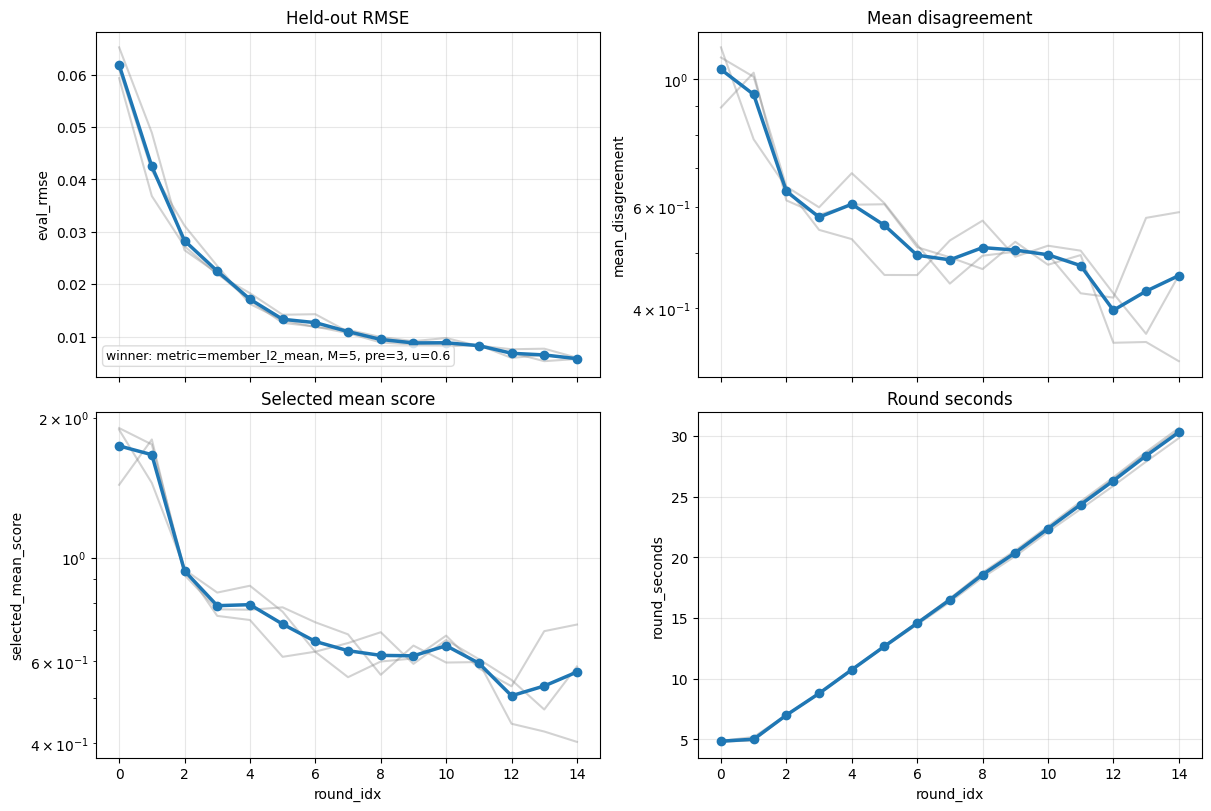

In [21]:
winner_cfg = best_stage1[stage1_param_cols].to_dict()

winner_mask = pd.Series(True, index=stage1_rounds.index)
for key, value in winner_cfg.items():
    winner_mask &= stage1_rounds[key].astype(str) == str(value)
winner_rounds = stage1_rounds.loc[winner_mask].copy()

winner_summary = (
    winner_rounds.groupby('seed')
    .agg(
        final_eval_rmse=('eval_rmse', 'last'),
        final_round_seconds=('round_seconds', 'last'),
        final_mean_disagreement=('mean_disagreement', 'last'),
        final_selected_mean_score=('selected_mean_score', 'last'),
    )
    .round(6)
)
display(winner_summary)

winner_mean = (
    winner_rounds.groupby('round_idx')[['eval_rmse', 'mean_disagreement', 'selected_mean_score', 'round_seconds']]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, constrained_layout=True)
metric_specs = [
    ('eval_rmse', 'Held-out RMSE', False),
    ('mean_disagreement', 'Mean disagreement', True),
    ('selected_mean_score', 'Selected mean score', True),
    ('round_seconds', 'Round seconds', False),
]

for ax, (metric, title, use_log) in zip(axes.flat, metric_specs):
    for seed, seed_df in winner_rounds.groupby('seed'):
        ax.plot(seed_df['round_idx'], seed_df[metric], color='gray', alpha=0.35, linewidth=1.5)
    ax.plot(winner_mean['round_idx'], winner_mean[metric], color='tab:blue', marker='o', linewidth=2.5)
    if use_log:
        ax.set_yscale('log')
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.grid(alpha=0.3)

winner_label = (
    f"winner: metric={winner_cfg['active.disagreement.metric']}, M={winner_cfg['qbc_M']}, "
    f"pre={winner_cfg['active.diversity.preselect_factor']}, u={winner_cfg['active.diversity.uncertainty_weight']}"
)
axes[0, 0].text(0.02, 0.05, winner_label, transform=axes[0, 0].transAxes, fontsize=9,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='lightgray'))
axes[1, 0].set_xlabel('round_idx')
axes[1, 1].set_xlabel('round_idx')
plt.show()


## Stage 2 Schedule Search

The policy is fixed and only the candidate pool size `qbc_P` is varied.

,qbc_P,n_seeds,mean_final_eval_rmse,std_final_eval_rmse,min_final_eval_rmse,max_final_eval_rmse,mean_final_round_seconds,mean_candidate_simulation_seconds
0,2048,3,0.002502,0.000479,0.002102,0.003033,122.695050,0.0
1,4096,3,0.003473,0.000629,0.002761,0.003952,125.358518,0.0
2,8192,3,0.002887,0.001028,0.002273,0.004074,126.205688,0.0


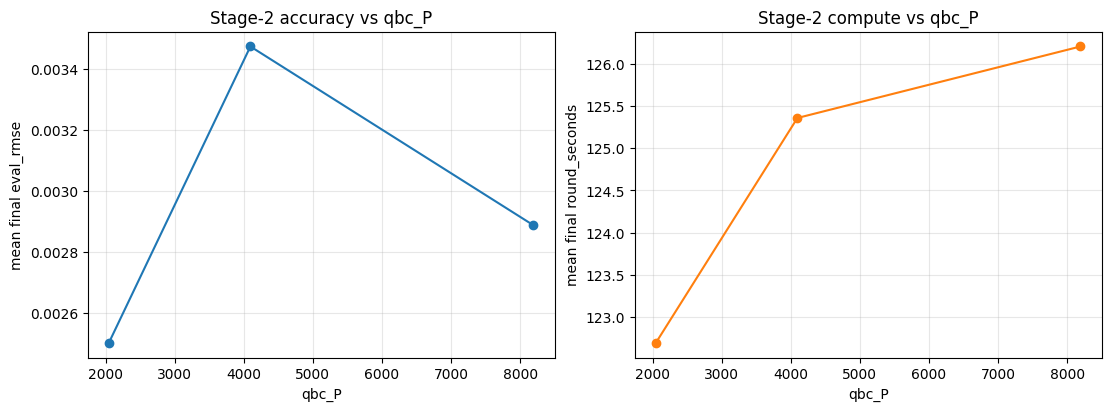

In [22]:
stage2_summary = (
    stage2_df.groupby('qbc_P', dropna=False)
    .agg(
        n_seeds=('seed', 'nunique'),
        mean_final_eval_rmse=('final_eval_rmse', 'mean'),
        std_final_eval_rmse=('final_eval_rmse', 'std'),
        min_final_eval_rmse=('final_eval_rmse', 'min'),
        max_final_eval_rmse=('final_eval_rmse', 'max'),
        mean_final_round_seconds=('final_round_seconds', 'mean'),
        mean_candidate_simulation_seconds=('final_candidate_simulation_seconds', 'mean'),
    )
    .reset_index()
    .sort_values('qbc_P')
)

display(stage2_summary)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(stage2_summary['qbc_P'].astype(int), stage2_summary['mean_final_eval_rmse'], marker='o')
axes[0].set_title('Stage-2 accuracy vs qbc_P')
axes[0].set_xlabel('qbc_P')
axes[0].set_ylabel('mean final eval_rmse')
axes[0].grid(alpha=0.3)

axes[1].plot(stage2_summary['qbc_P'].astype(int), stage2_summary['mean_final_round_seconds'], marker='o', color='tab:orange')
axes[1].set_title('Stage-2 compute vs qbc_P')
axes[1].set_xlabel('qbc_P')
axes[1].set_ylabel('mean final round_seconds')
axes[1].grid(alpha=0.3)

plt.show()

## 2. Marker-Directed

This section mirrors the QBC setup, but keeps all variables local to marker-directed so the two analyses stay separate.

In [23]:
MARKER_RESULTS_ROOT = REPO_ROOT / 'hpo' / 'results' / 'marker_directed'
MARKER_STAGE1_ROOT = sorted((MARKER_RESULTS_ROOT / 'stage1_policy_search').iterdir())[-1]
MARKER_STAGE2_ROOT = sorted((MARKER_RESULTS_ROOT / 'stage2_schedule_search').iterdir())[-1]

CFG_MARKER_STAGE1 = OmegaConf.to_container(
    OmegaConf.load(REPO_ROOT / 'hpo' / 'workflow_configs' / 'marker_directed' / 'sm4.yaml'),
    resolve=True,
)

marker_stage1_df, marker_stage1_rounds = load_hpo_run(MARKER_STAGE1_ROOT)
marker_stage2_df, marker_stage2_rounds = load_hpo_run(MARKER_STAGE2_ROOT)

print('MARKER_STAGE1_ROOT:', MARKER_STAGE1_ROOT)
print('MARKER_STAGE2_ROOT:', MARKER_STAGE2_ROOT)
print('marker stage1 rows:', len(marker_stage1_df), 'marker stage1 round rows:', len(marker_stage1_rounds))
print('marker stage2 rows:', len(marker_stage2_df), 'marker stage2 round rows:', len(marker_stage2_rounds))

MARKER_STAGE1_ROOT: /Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems/hpo/results/marker_directed/stage1_policy_search/marker_directed_policy_search_20260302_112434
MARKER_STAGE2_ROOT: /Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems/hpo/results/marker_directed/stage2_schedule_search/marker_directed_schedule_search_20260302_165806
marker stage1 rows: 144 marker stage1 round rows: 2160
marker stage2 rows: 9 marker stage2 round rows: 279


### Marker Stage 1 Summary

The stage-1 marker search varies the marker geometry and greedy selection settings. As for QBC, the main HPO outcome is the final held-out `eval_rmse` aggregated across the three seeds.

In [24]:
marker_stage1_param_cols = [
    'active.marker.pca_explained_variance',
    'active.marker.k_density',
    'active.marker.preselect_factor',
    'active.marker.greedy_score_weight',
    'active.marker.weights.diversity',
]

marker_stage1_ranked = (
    marker_stage1_df.groupby(marker_stage1_param_cols, dropna=False)
    .agg(
        n_seeds=('seed', 'nunique'),
        mean_final_eval_rmse=('final_eval_rmse', 'mean'),
        std_final_eval_rmse=('final_eval_rmse', 'std'),
        min_final_eval_rmse=('final_eval_rmse', 'min'),
        max_final_eval_rmse=('final_eval_rmse', 'max'),
        mean_final_round_seconds=('final_round_seconds', 'mean'),
    )
    .reset_index()
    .sort_values(['mean_final_eval_rmse', 'std_final_eval_rmse'])
)

marker_best_stage1 = marker_stage1_ranked.iloc[0].copy()

marker_stage1_summary_table = (
    marker_stage1_ranked[
        [
            'active.marker.pca_explained_variance',
            'active.marker.k_density',
            'active.marker.preselect_factor',
            'active.marker.greedy_score_weight',
            'active.marker.weights.diversity',
            'mean_final_eval_rmse',
            'std_final_eval_rmse',
            'min_final_eval_rmse',
            'max_final_eval_rmse',
            'mean_final_round_seconds',
            'n_seeds',
        ]
    ]
    .rename(
        columns={
            'active.marker.pca_explained_variance': 'pca_explained_variance',
            'active.marker.k_density': 'k_density',
            'active.marker.preselect_factor': 'preselect_factor',
            'active.marker.greedy_score_weight': 'greedy_score_weight',
            'active.marker.weights.diversity': 'diversity_weight',
            'mean_final_eval_rmse': 'rmse_mean',
            'std_final_eval_rmse': 'rmse_std',
            'min_final_eval_rmse': 'rmse_min',
            'max_final_eval_rmse': 'rmse_max',
            'mean_final_round_seconds': 'round_seconds_mean',
        }
    )
    .round(
        {
            'rmse_mean': 6,
            'rmse_std': 6,
            'rmse_min': 6,
            'rmse_max': 6,
            'round_seconds_mean': 2,
        }
    )
)

display(marker_stage1_summary_table.head(12))

,pca_explained_variance,k_density,preselect_factor,greedy_score_weight,diversity_weight,rmse_mean,rmse_std,rmse_min,rmse_max,round_seconds_mean,n_seeds
25,0.95,10,3,0.7,0.6,0.007217,0.000290,0.007047,0.007551,25.72,3
24,0.95,10,3,0.7,0.4,0.007326,0.000839,0.006543,0.008212,25.59,3
38,0.95,20,3,0.7,0.8,0.007392,0.000455,0.007058,0.007910,25.84,3
14,0.9,20,3,0.7,0.8,0.007423,0.000217,0.007206,0.007640,25.98,3
32,0.95,10,5,0.7,0.8,0.007469,0.000680,0.006900,0.008221,25.97,3
1,0.9,10,3,0.7,0.6,0.007482,0.000402,0.007047,0.007840,25.76,3
41,0.95,20,3,0.9,0.8,0.007508,0.000678,0.006730,0.007974,25.79,3
21,0.9,20,5,0.9,0.4,0.007529,0.000388,0.007241,0.007970,25.87,3
16,0.9,20,3,0.9,0.6,0.007538,0.000281,0.007219,0.007748,25.82,3
9,0.9,10,5,0.9,0.4,0.007551,0.000199,0.007379,0.007769,25.83,3


### Marker Parameter Effects

These views focus on the marker-specific mechanics. The tables show marginal effects, the plots show average effect size with uncertainty, and the interaction heatmaps show where the geometry and selection settings work well together.

In [29]:
for col in marker_stage1_param_cols:
    summary = (
        marker_stage1_df.groupby(col, dropna=False)['final_eval_rmse']
        .agg(['mean', 'std', 'min', 'max', 'count'])
        .sort_index()
        .round(6)
    )
    print(f'Effect of {col} on final_eval_rmse:')
    display(summary)


Effect of active.marker.pca_explained_variance on final_eval_rmse:


,mean,std,min,max,count
active.marker.pca_explained_variance,,,,,
0.9,0.007924,0.000803,0.006543,0.01056,72
0.95,0.007836,0.000838,0.006543,0.01056,72


Effect of active.marker.k_density on final_eval_rmse:


,mean,std,min,max,count
active.marker.k_density,,,,,
10,0.007763,0.000719,0.006543,0.010005,72
20,0.007996,0.000899,0.006730,0.010560,72


Effect of active.marker.preselect_factor on final_eval_rmse:


,mean,std,min,max,count
active.marker.preselect_factor,,,,,
3,0.007825,0.000871,0.006543,0.010560,72
5,0.007935,0.000766,0.006831,0.010347,72


Effect of active.marker.greedy_score_weight on final_eval_rmse:


,mean,std,min,max,count
active.marker.greedy_score_weight,,,,,
0.7,0.007871,0.000879,0.006543,0.010560,72
0.9,0.007888,0.000761,0.006700,0.010005,72


Effect of active.marker.weights.diversity on final_eval_rmse:


,mean,std,min,max,count
active.marker.weights.diversity,,,,,
0.4,0.007941,0.000956,0.006543,0.010560,48
0.6,0.007829,0.000653,0.007047,0.009876,48
0.8,0.007869,0.000834,0.006699,0.010347,48


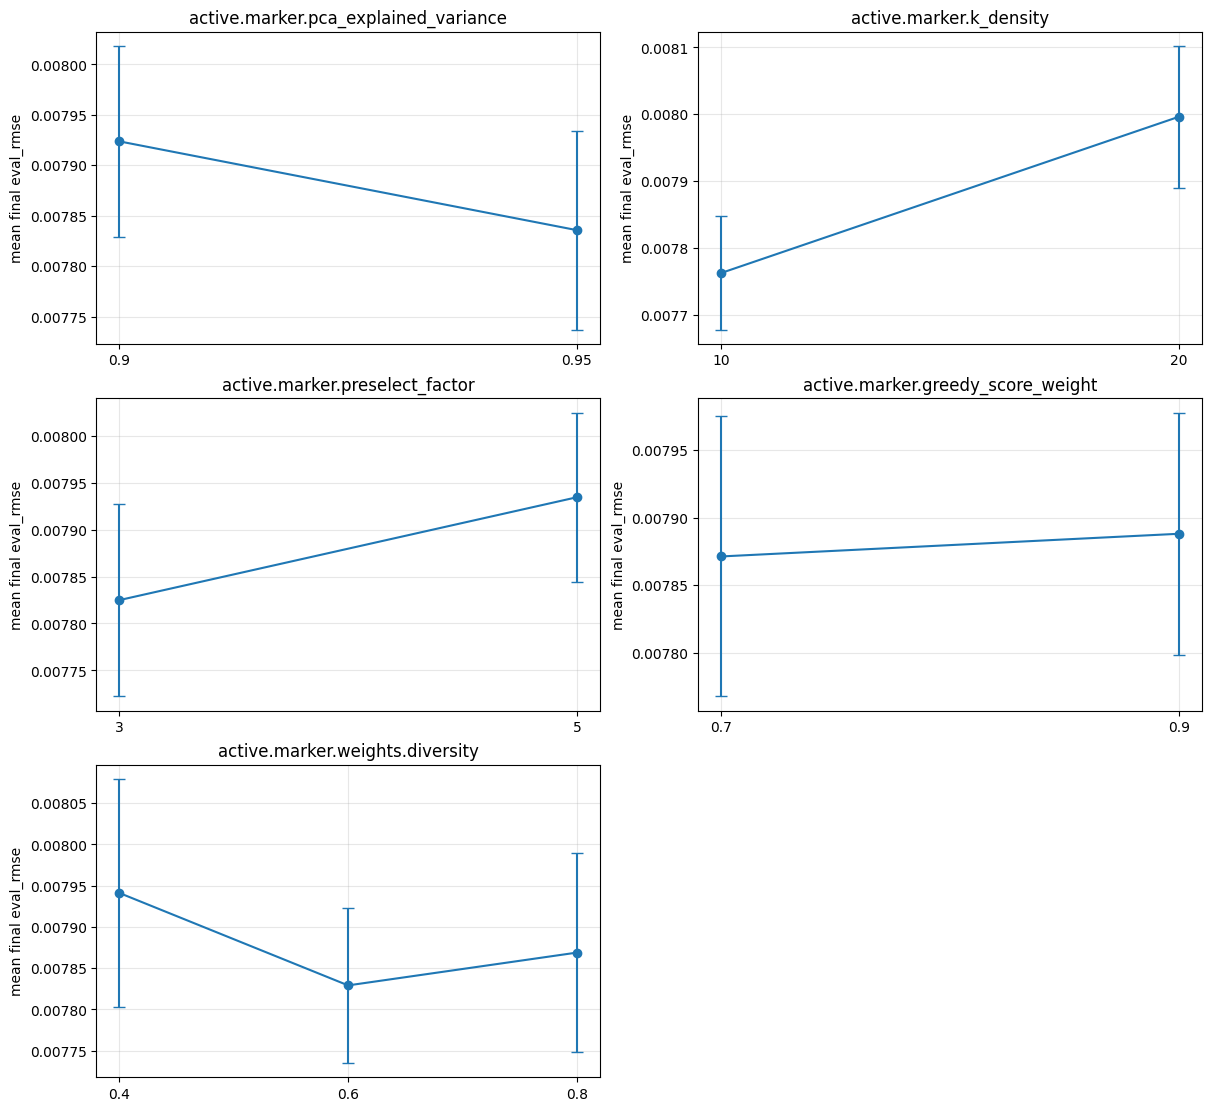

In [26]:
fig, axes = plt.subplots(3, 2, figsize=(12, 11), constrained_layout=True)
effect_axes = axes.flat

for ax, col in zip(effect_axes, marker_stage1_param_cols):
    effect = (
        marker_stage1_df.groupby(col, dropna=False)['final_eval_rmse']
        .agg(['mean', 'std', 'count'])
        .reset_index()
        .sort_values(col)
    )
    effect['se'] = effect['std'] / np.sqrt(effect['count'])
    x = effect[col].astype(str)
    ax.errorbar(x=x, y=effect['mean'], yerr=effect['se'], fmt='o-', capsize=4)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('mean final eval_rmse')
    ax.grid(alpha=0.3)

effect_axes[-1].axis('off')
plt.show()


### Marker Interaction Views

These heatmaps isolate two interactions that matter for marker-directed behavior: local density with PCA geometry, and the balance between greedy selection and diversity weighting.

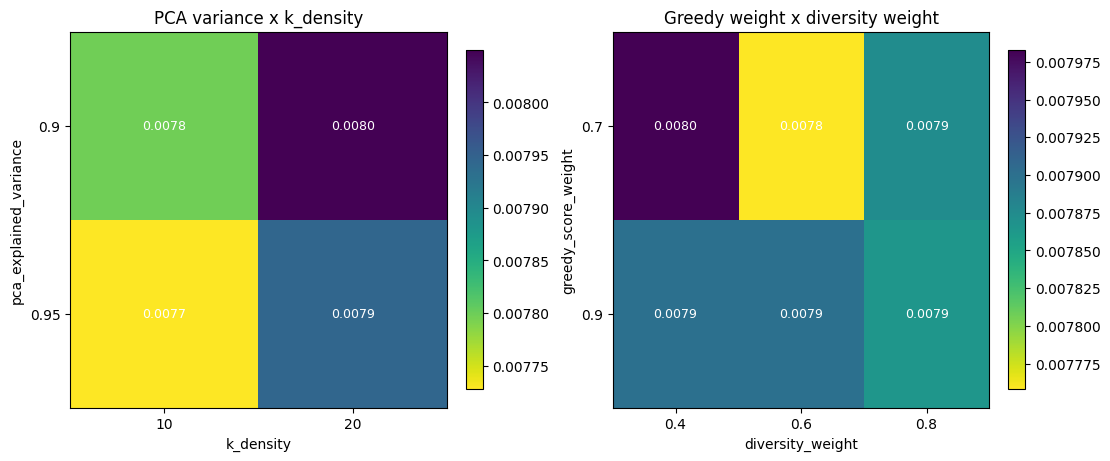

In [27]:
marker_heat_1 = (
    marker_stage1_df.groupby(
        ['active.marker.pca_explained_variance', 'active.marker.k_density'],
        dropna=False,
    )['final_eval_rmse']
    .mean()
    .reset_index()
    .pivot(index='active.marker.pca_explained_variance', columns='active.marker.k_density', values='final_eval_rmse')
)

marker_heat_2 = (
    marker_stage1_df.groupby(
        ['active.marker.greedy_score_weight', 'active.marker.weights.diversity'],
        dropna=False,
    )['final_eval_rmse']
    .mean()
    .reset_index()
    .pivot(index='active.marker.greedy_score_weight', columns='active.marker.weights.diversity', values='final_eval_rmse')
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
for ax, heat, title, xlabel, ylabel in [
    (axes[0], marker_heat_1, 'PCA variance x k_density', 'k_density', 'pca_explained_variance'),
    (axes[1], marker_heat_2, 'Greedy weight x diversity weight', 'diversity_weight', 'greedy_score_weight'),
]:
    im = ax.imshow(heat.to_numpy(dtype=float), cmap='viridis_r', aspect='auto')
    ax.set_xticks(range(len(heat.columns)), [str(x) for x in heat.columns])
    ax.set_yticks(range(len(heat.index)), [str(x) for x in heat.index])
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    for y in range(len(heat.index)):
        for x in range(len(heat.columns)):
            ax.text(x, y, f'{heat.iloc[y, x]:.4f}', ha='center', va='center', color='white', fontsize=9)
    fig.colorbar(im, ax=ax, shrink=0.9)

plt.show()


### Marker Winner Telemetry

For marker-directed, the most informative round telemetry is the marker selection behavior itself. These plots show whether the winning configuration keeps selecting novel, sparse, high-score candidates and how the per-round cost evolves.

,final_eval_rmse,final_selected_mean_score,final_selected_mean_marker_diversity,final_selected_mean_marker_sparsity,final_round_seconds
seed,,,,,
s01,0.007551,0.184564,0.530083,0.803703,25.725303
s02,0.007052,0.388790,0.500801,0.759544,25.783909
s03,0.007047,0.555608,0.498208,0.764388,25.659317


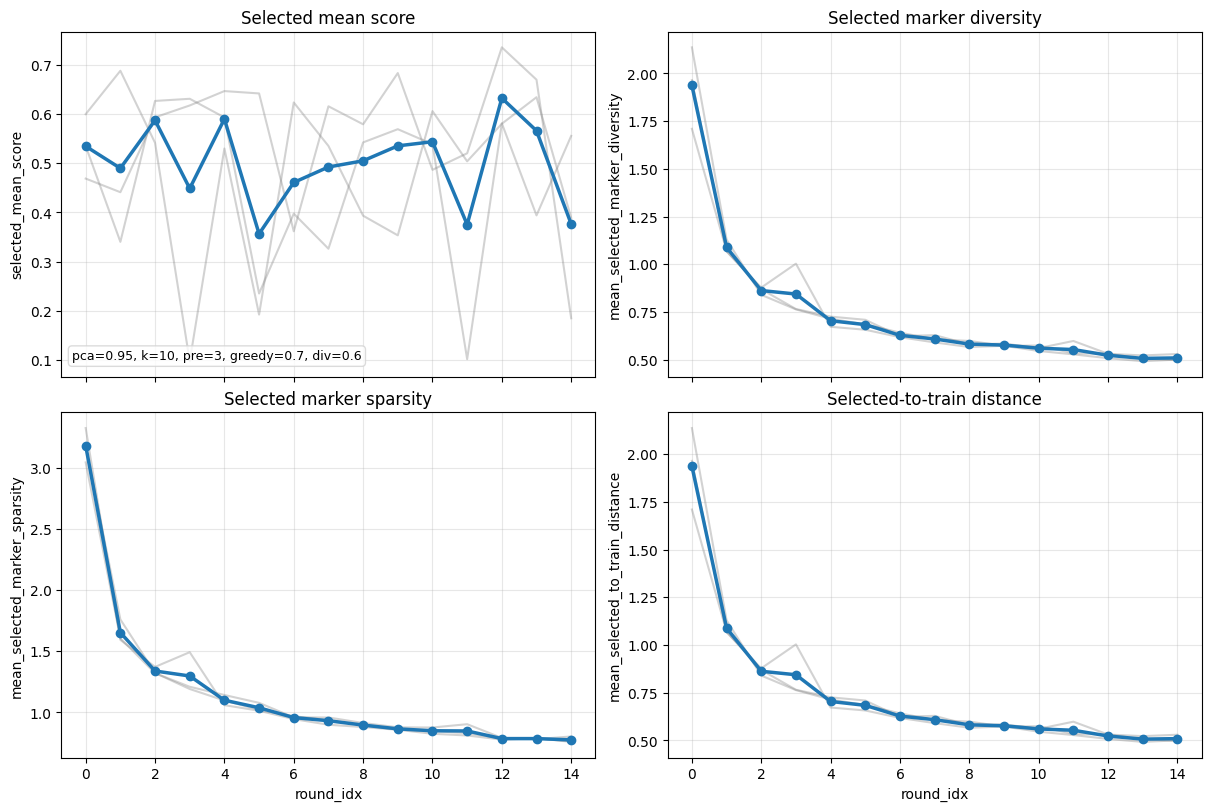

In [32]:
marker_winner_cfg = marker_best_stage1[marker_stage1_param_cols].to_dict()

marker_winner_mask = pd.Series(True, index=marker_stage1_rounds.index)
for key, value in marker_winner_cfg.items():
    marker_winner_mask &= marker_stage1_rounds[key].astype(str) == str(value)
marker_winner_rounds = marker_stage1_rounds.loc[marker_winner_mask].copy()

marker_winner_summary = (
    marker_winner_rounds.groupby('seed')
    .agg(
        final_eval_rmse=('eval_rmse', 'last'),
        final_selected_mean_score=('selected_mean_score', 'last'),
        final_selected_mean_marker_diversity=('mean_selected_marker_diversity', 'last'),
        final_selected_mean_marker_sparsity=('mean_selected_marker_sparsity', 'last'),
        final_round_seconds=('round_seconds', 'last'),
    )
    .round(6)
)
display(marker_winner_summary)

marker_winner_mean = (
    marker_winner_rounds.groupby('round_idx')[[
        'selected_mean_score',
        'mean_selected_marker_diversity',
        'mean_selected_marker_sparsity',
        'mean_selected_to_train_distance',
        'round_seconds',
    ]]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, constrained_layout=True)
plot_specs = [
    ('selected_mean_score', 'Selected mean score'),
    ('mean_selected_marker_diversity', 'Selected marker diversity'),
    ('mean_selected_marker_sparsity', 'Selected marker sparsity'),
    ('mean_selected_to_train_distance', 'Selected-to-train distance'),
]

for ax, (metric, title) in zip(axes.flat, plot_specs):
    for seed, seed_df in marker_winner_rounds.groupby('seed'):
        ax.plot(seed_df['round_idx'], seed_df[metric], color='gray', alpha=0.35, linewidth=1.5)
    ax.plot(marker_winner_mean['round_idx'], marker_winner_mean[metric], color='tab:blue', marker='o', linewidth=2.5)
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.grid(alpha=0.3)

axes[1, 0].set_xlabel('round_idx')
axes[1, 1].set_xlabel('round_idx')
winner_text = (
    f"pca={marker_winner_cfg['active.marker.pca_explained_variance']}, "
    f"k={marker_winner_cfg['active.marker.k_density']}, "
    f"pre={marker_winner_cfg['active.marker.preselect_factor']}, "
    f"greedy={marker_winner_cfg['active.marker.greedy_score_weight']}, "
    f"div={marker_winner_cfg['active.marker.weights.diversity']}"
)
axes[0, 0].text(0.02, 0.05, winner_text, transform=axes[0, 0].transAxes, fontsize=9,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='lightgray'))
plt.show()


### Marker Stage 2 Schedule Search

Stage 2 keeps the marker policy fixed and only varies the candidate pool size `qbc_P`. The table and plot below show the accuracy-cost tradeoff across the three seeds.

,qbc_P,n_seeds,mean_final_eval_rmse,std_final_eval_rmse,min_final_eval_rmse,max_final_eval_rmse,mean_final_round_seconds,mean_candidate_simulation_seconds,mean_acquisition_seconds
0,2048,3,0.003368,0.000726,0.002799,0.004186,83.63,5.67,1.61
1,4096,3,0.003077,0.000453,0.002652,0.003553,89.69,11.19,2.13
2,8192,3,0.003730,0.000573,0.003290,0.004378,102.29,22.48,3.03


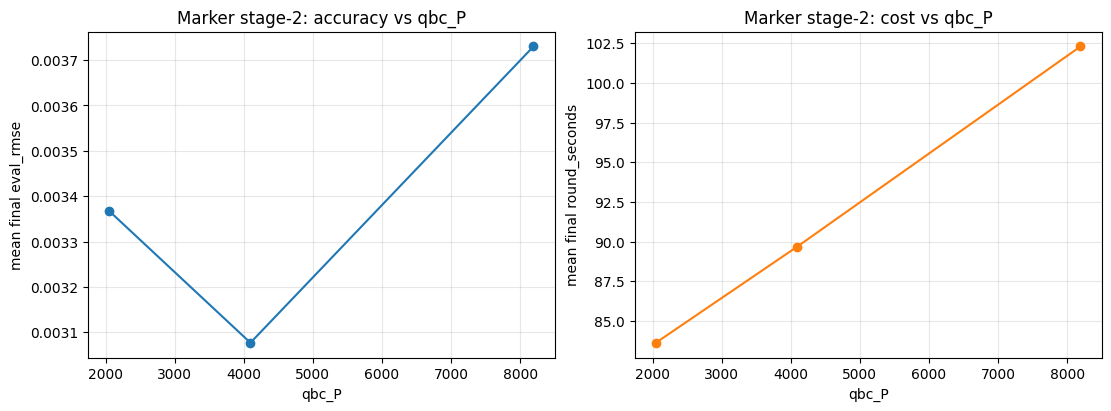

In [16]:
marker_stage2_summary = (
    marker_stage2_df.groupby('qbc_P', dropna=False)
    .agg(
        n_seeds=('seed', 'nunique'),
        mean_final_eval_rmse=('final_eval_rmse', 'mean'),
        std_final_eval_rmse=('final_eval_rmse', 'std'),
        min_final_eval_rmse=('final_eval_rmse', 'min'),
        max_final_eval_rmse=('final_eval_rmse', 'max'),
        mean_final_round_seconds=('final_round_seconds', 'mean'),
        mean_candidate_simulation_seconds=('final_candidate_simulation_seconds', 'mean'),
        mean_acquisition_seconds=('final_acquisition_seconds', 'mean'),
    )
    .reset_index()
    .sort_values('qbc_P')
    .round(
        {
            'mean_final_eval_rmse': 6,
            'std_final_eval_rmse': 6,
            'min_final_eval_rmse': 6,
            'max_final_eval_rmse': 6,
            'mean_final_round_seconds': 2,
            'mean_candidate_simulation_seconds': 2,
            'mean_acquisition_seconds': 2,
        }
    )
)

display(marker_stage2_summary)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(marker_stage2_summary['qbc_P'].astype(int), marker_stage2_summary['mean_final_eval_rmse'], marker='o')
axes[0].set_title('Marker stage-2: accuracy vs qbc_P')
axes[0].set_xlabel('qbc_P')
axes[0].set_ylabel('mean final eval_rmse')
axes[0].grid(alpha=0.3)

axes[1].plot(marker_stage2_summary['qbc_P'].astype(int), marker_stage2_summary['mean_final_round_seconds'], marker='o', color='tab:orange')
axes[1].set_title('Marker stage-2: cost vs qbc_P')
axes[1].set_xlabel('qbc_P')
axes[1].set_ylabel('mean final round_seconds')
axes[1].grid(alpha=0.3)

plt.show()
